# Introduction to Statistical Methods for Atmospheric Data Analysis

This notebook introduces the statistical techniques you will use in the Chilbolton climatology project. All examples use simple, self-contained datasets before you apply the same methods to the real observatory data.

**Topics covered:**
1. Descriptive statistics — mean, standard deviation, percentiles
2. Histograms and probability density functions (PDFs)
3. Fitting distributions — Normal and Weibull
4. Exceedance curves
5. Groupby aggregation — monthly and seasonal climatology
6. Time-series resampling
7. Linear regression and trend detection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

rng = np.random.default_rng(42)   # fixed seed for reproducibility
print('Libraries loaded.')

Libraries loaded.


---
## 1. Descriptive Statistics

Descriptive statistics summarise a dataset with a few numbers. The most important are:

| Statistic | Meaning | NumPy / pandas |
|---|---|---|
| Mean | Average value | `np.mean()` / `.mean()` |
| Standard deviation | Spread around the mean | `np.std()` / `.std()` |
| Min / Max | Extreme values | `np.min()`, `np.max()` |
| Percentile | Value below which X% of data falls | `np.percentile(data, q)` |

We generate synthetic pressure data similar to what you will see at Chilbolton:

In [3]:
# Simulate ~1 year of hourly surface pressure (hPa)
n = 8760   # hours in a year
pressure = rng.normal(loc=1013.0, scale=8.5, size=n)

print(f'Number of values : {n}')
print(f'Mean             : {np.mean(pressure):.2f} hPa')
print(f'Standard dev     : {np.std(pressure):.2f} hPa')
print(f'Min              : {np.min(pressure):.1f} hPa')
print(f'Max              : {np.max(pressure):.1f} hPa')
print(f'5th  percentile  : {np.percentile(pressure, 5):.1f} hPa  (deep lows)')
print(f'95th percentile  : {np.percentile(pressure, 95):.1f} hPa  (strong highs)')

Number of values : 8760
Mean             : 1012.95 hPa
Standard dev     : 8.50 hPa
Min              : 975.7 hPa
Max              : 1047.2 hPa
5th  percentile  : 999.0 hPa  (deep lows)
95th percentile  : 1026.9 hPa  (strong highs)


**Why percentiles?** The 5th and 95th percentiles mark the extreme 10% of the distribution — useful for identifying unusually low or high pressure events without being misled by individual outliers.

---
## 2. Histograms and Probability Density Functions

A **histogram** shows how frequently values fall in each bin. Setting `density=True` normalises the y-axis so that the histogram integrates to 1 — this is called a **probability density function (PDF)** estimate. Only a normalised histogram can be fairly compared to a theoretical distribution curve.

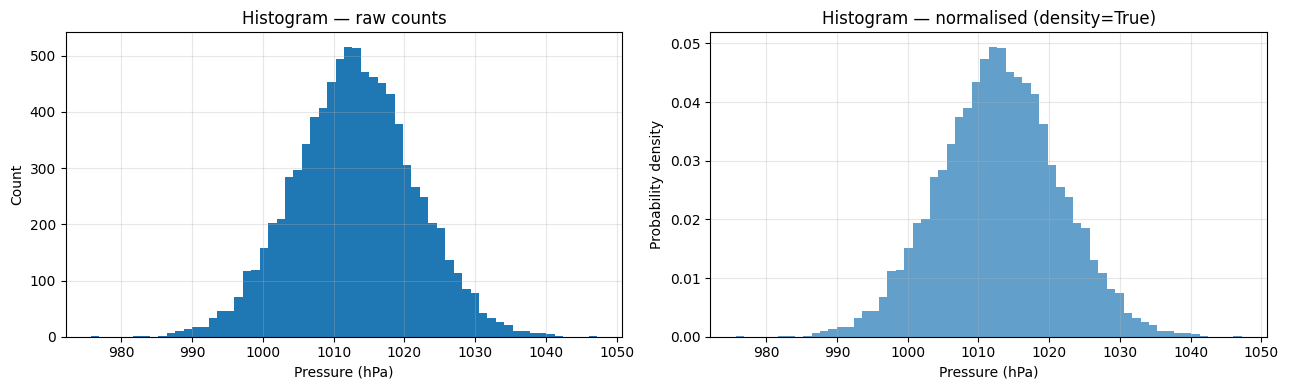

Note: the shapes are identical, but only the right-hand plot has a y-axis that can be compared to a PDF curve.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw counts (NOT comparable to a PDF)
axes[0].hist(pressure, bins=60)
axes[0].set_xlabel('Pressure (hPa)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram — raw counts')
axes[0].grid(True, alpha=0.3)

# Right: normalised density (comparable to a PDF)
axes[1].hist(pressure, bins=60, density=True, alpha=0.7)
axes[1].set_xlabel('Pressure (hPa)')
axes[1].set_ylabel('Probability density')
axes[1].set_title('Histogram — normalised (density=True)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
print('Note: the shapes are identical, but only the right-hand plot has a y-axis that can be compared to a PDF curve.')

---
## 3. Fitting Probability Distributions

`scipy.stats` can fit a wide range of theoretical distributions to data using **Maximum Likelihood Estimation (MLE)** — it finds the distribution parameters that make the observed data most probable.

### 3a. The Normal Distribution (pressure, temperature)

The Normal (Gaussian) distribution is symmetrical and characterised by two parameters:
- **μ (mu)** — the mean
- **σ (sigma)** — the standard deviation

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Surface pressure is well described by a Normal distribution.

Fitted Normal: μ = 1012.95 hPa,  σ = 8.50 hPa


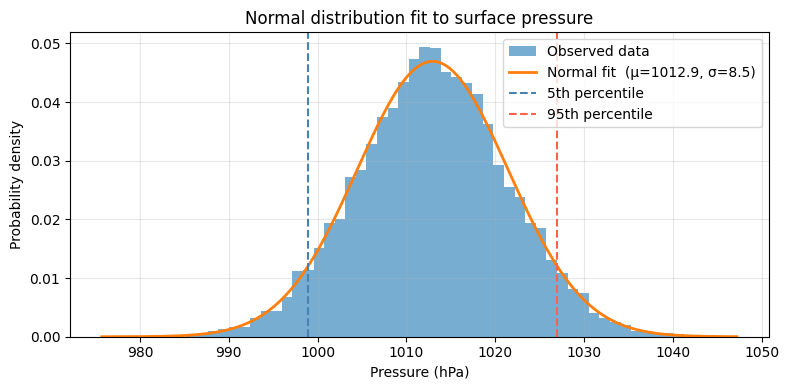

In [5]:
# Fit a Normal distribution
mu, sigma = scipy.stats.norm.fit(pressure)
print(f'Fitted Normal: μ = {mu:.2f} hPa,  σ = {sigma:.2f} hPa')

x = np.linspace(pressure.min(), pressure.max(), 400)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pressure, bins=60, density=True, alpha=0.6, label='Observed data')
ax.plot(x, scipy.stats.norm.pdf(x, mu, sigma), linewidth=2,
        label=f'Normal fit  (μ={mu:.1f}, σ={sigma:.1f})')
ax.axvline(np.percentile(pressure, 5),  linestyle='--', color='steelblue', label='5th percentile')
ax.axvline(np.percentile(pressure, 95), linestyle='--', color='tomato',    label='95th percentile')
ax.set_xlabel('Pressure (hPa)')
ax.set_ylabel('Probability density')
ax.set_title('Normal distribution fit to surface pressure')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 3b. The Weibull Distribution (wind speed)

Wind speed **cannot** be negative, and its distribution is skewed — many calm periods and a long tail of high speeds. The **Weibull distribution** captures this shape:

$$f(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1} \exp\!\left(-\left(\frac{x}{\lambda}\right)^k\right), \quad x \geq 0$$

Parameters:
- **k** (shape) — controls the skewness; typical UK sites have k ≈ 1.5–2.5
- **λ** (scale, `scale` in scipy) — related to the mean wind speed

We fix `loc=0` (`floc=0`) because wind speed cannot be below zero.

Fitted Weibull: shape k = 1.80,  scale λ = 5.03 m/s
(True values:   k = 1.80,  λ = 5.00 m/s)


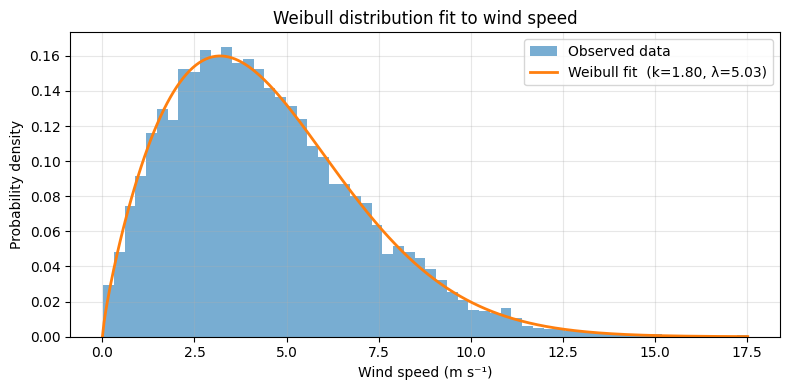

In [6]:
# Simulate wind speed data: Weibull with k=1.8, lambda=5 m/s
wind_speed = rng.weibull(1.8, size=n) * 5.0

# Fit Weibull — fix loc=0 because speed cannot be negative
k, loc, lam = scipy.stats.weibull_min.fit(wind_speed, floc=0)
print(f'Fitted Weibull: shape k = {k:.2f},  scale λ = {lam:.2f} m/s')
print(f'(True values:   k = 1.80,  λ = 5.00 m/s)')

x = np.linspace(0, wind_speed.max(), 400)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(wind_speed, bins=60, density=True, alpha=0.6, label='Observed data')
ax.plot(x, scipy.stats.weibull_min.pdf(x, k, loc, lam), linewidth=2,
        label=f'Weibull fit  (k={k:.2f}, λ={lam:.2f})')
ax.set_xlabel('Wind speed (m s⁻¹)')
ax.set_ylabel('Probability density')
ax.set_title('Weibull distribution fit to wind speed')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Key point:** Use the *right distribution for the variable*:
- **Pressure / temperature** → Normal
- **Wind speed / rainfall amounts** → Weibull or similar skewed distributions

---
## 4. Exceedance Curves

An **exceedance curve** (or complementary CDF) shows the probability that a value *exceeds* a given threshold. It is plotted on a **semi-logarithmic scale** so that rare extreme events in the tail are visible.

Construction:
1. Sort values from largest to smallest
2. Assign each value a plotting position: $P_i = (i - 0.5) / N$ where $i = 1, 2, \ldots, N$
3. Plot value on x-axis, $P_i$ on y-axis (log scale)

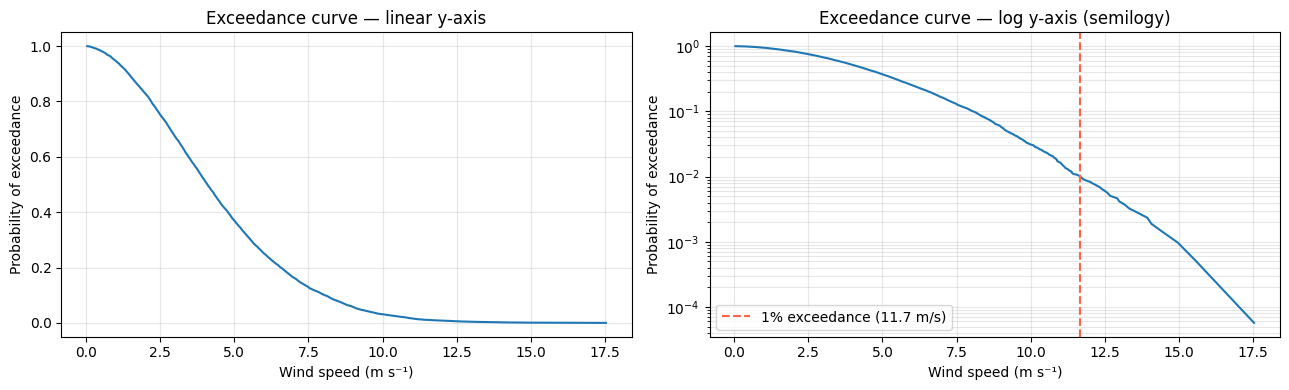

Wind speed exceeded 1% of the time: 11.7 m/s


In [7]:
spd_sorted = np.sort(wind_speed)[::-1]   # descending order
n_pts = len(spd_sorted)
exceedance = (np.arange(n_pts) + 0.5) / n_pts

# Thin data for efficient plotting
thin = max(1, n_pts // 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale — tail hard to see
axes[0].plot(spd_sorted[::thin], exceedance[::thin], linewidth=1.5)
axes[0].set_xlabel('Wind speed (m s⁻¹)')
axes[0].set_ylabel('Probability of exceedance')
axes[0].set_title('Exceedance curve — linear y-axis')
axes[0].grid(True, alpha=0.3)

# Log scale — tail is now clearly visible
axes[1].semilogy(spd_sorted[::thin], exceedance[::thin], linewidth=1.5)
axes[1].set_xlabel('Wind speed (m s⁻¹)')
axes[1].set_ylabel('Probability of exceedance')
axes[1].set_title('Exceedance curve — log y-axis (semilogy)')
axes[1].grid(True, which='both', alpha=0.3)

# Annotate 1% exceedance threshold
p99 = np.percentile(wind_speed, 99)
axes[1].axvline(p99, linestyle='--', color='tomato', label=f'1% exceedance ({p99:.1f} m/s)')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f'Wind speed exceeded 1% of the time: {p99:.1f} m/s')

---
## 5. Groupby Aggregation — Monthly and Seasonal Climatology

Pandas `.groupby()` splits a DataFrame by a key, applies a function to each group, and combines the results. This is the standard approach for computing monthly or seasonal climatologies.

In [8]:
# Build a synthetic year of hourly data in a DataFrame
times = pd.date_range('2020-01-01', periods=n, freq='h', tz='UTC')
df = pd.DataFrame({'time': times, 'pressure': pressure, 'wind_speed': wind_speed})

# Group by calendar month and compute multiple statistics at once
monthly = df.groupby(df['time'].dt.month)['pressure'].agg(['mean', 'std', 'count'])
monthly.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(monthly.round(2))

        mean   std  count
Jan  1012.59  8.37    744
Feb  1013.06  8.61    696
Mar  1012.15  8.46    744
Apr  1013.20  8.66    720
May  1013.42  8.41    744
Jun  1012.85  8.39    720
Jul  1012.48  8.49    744
Aug  1013.42  8.61    744
Sep  1013.55  8.87    720
Oct  1013.04  8.28    744
Nov  1012.36  8.48    720
Dec  1013.26  8.27    720


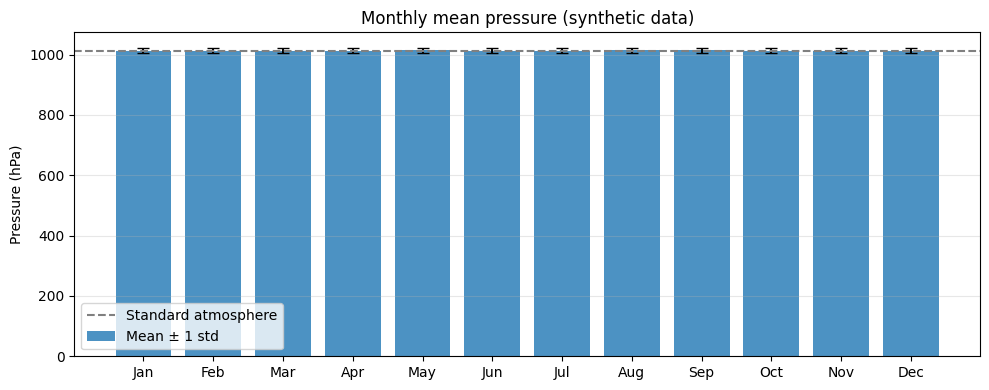

In [9]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(12)
ax.bar(x, monthly['mean'], yerr=monthly['std'], capsize=4, alpha=0.8, label='Mean ± 1 std')
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Monthly mean pressure (synthetic data)')
ax.axhline(1013.25, linestyle='--', color='grey', label='Standard atmosphere')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

You can group by *any* column or derived quantity. Common patterns with datetime data:

```python
df.groupby(df['time'].dt.month)     # monthly
df.groupby(df['time'].dt.year)      # annual
df.groupby(df['season'])            # seasonal (add a 'season' column first)
df.groupby([df['time'].dt.year,
            df['time'].dt.month])   # year × month
```

---
## 6. Time-Series Resampling

**Resampling** changes the temporal resolution of a time series — e.g. aggregating 10-second observations into hourly means. This reduces noise and makes long-period plots clearer.

Syntax:
```python
df.set_index('time').resample('h')['variable'].mean()
```
Common frequency strings: `'10s'`, `'min'`, `'h'`, `'D'`, `'ME'` (month end), `'YE'` (year end).

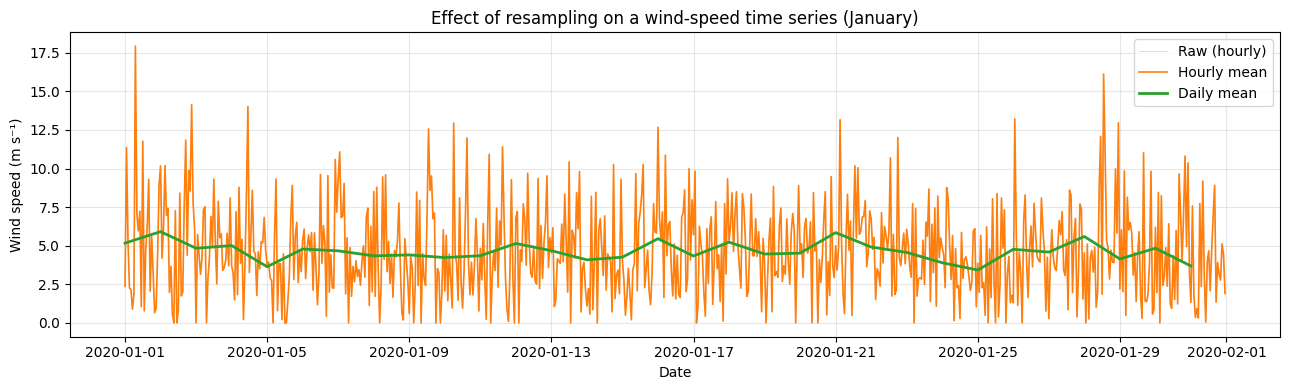

In [10]:
# Add short-timescale noise to simulate raw 10-s data → then smooth
df['wind_noisy'] = df['wind_speed'] + rng.normal(0, 1.5, n)
df['wind_noisy'] = df['wind_noisy'].clip(lower=0)

hourly = df.set_index('time').resample('h')['wind_noisy'].mean().reset_index()
daily  = df.set_index('time').resample('D')['wind_noisy'].mean().reset_index()

# Plot January only
jan_raw    = df[df['time'].dt.month == 1]
jan_hourly = hourly[hourly['time'].dt.month == 1]
jan_daily  = daily[daily['time'].dt.month == 1]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(jan_raw['time'],    jan_raw['wind_noisy'],    alpha=0.3, linewidth=0.5, label='Raw (hourly)')
ax.plot(jan_hourly['time'], jan_hourly['wind_noisy'], linewidth=1.2,            label='Hourly mean')
ax.plot(jan_daily['time'],  jan_daily['wind_noisy'],  linewidth=2.0,            label='Daily mean')
ax.set_xlabel('Date')
ax.set_ylabel('Wind speed (m s⁻¹)')
ax.set_title('Effect of resampling on a wind-speed time series (January)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 7. Linear Regression and Trend Detection

`scipy.stats.linregress` fits a straight line $y = mx + c$ to data and returns:

| Return value | Meaning |
|---|---|
| `slope` | Gradient $m$ (units: y-units per x-unit) |
| `intercept` | y-intercept $c$ |
| `rvalue` | Pearson correlation coefficient $r$ |
| `pvalue` | p-value for the null hypothesis that slope = 0 |
| `stderr` | Standard error of the slope |

**Interpreting the p-value:** if p > 0.05, the trend is *not* statistically significant at the 95% confidence level — the data are consistent with no trend.

In [11]:
# Example 1: genuine trend
years = np.arange(2000, 2026)
temperature_trend = 10.5 + 0.04 * (years - 2000) + rng.normal(0, 0.4, len(years))

slope, intercept, r, p, se = scipy.stats.linregress(years, temperature_trend)
print('=== Example with a real trend ===')
print(f'Slope     : {slope:.4f} °C / year')
print(f'R²        : {r**2:.3f}')
print(f'p-value   : {p:.4f}  ({"significant" if p < 0.05 else "NOT significant"})')

# Example 2: no trend
pressure_flat = 1013.0 + rng.normal(0, 2.0, len(years))
slope2, intercept2, r2, p2, se2 = scipy.stats.linregress(years, pressure_flat)
print()
print('=== Example with NO trend ===')
print(f'Slope     : {slope2:.4f} hPa / year')
print(f'R²        : {r2**2:.3f}')
print(f'p-value   : {p2:.4f}  ({"significant" if p2 < 0.05 else "NOT significant"})')

=== Example with a real trend ===
Slope     : 0.0278 °C / year
R²        : 0.218
p-value   : 0.0161  (significant)

=== Example with NO trend ===
Slope     : -0.0780 hPa / year
R²        : 0.104
p-value   : 0.1084  (NOT significant)


### Understanding R² and the p-value

Two numbers from `scipy.stats.linregress` are commonly misunderstood — here is what they actually mean.

#### R² — coefficient of determination

R² measures how much of the **variance** in y is explained by the linear relationship with x. It ranges from 0 to 1:

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

| R² value | Meaning |
|---|---|
| 1.0 | Perfect linear fit — the line passes through every point |
| 0.5 | The trend explains 50% of the variance; the other 50% is unexplained scatter |
| 0.0 | The line explains none of the variance — no better than using the mean |

**Important:** a high R² does not prove causation, and a low R² does not mean there is no trend — it just means the trend is small compared to the year-to-year scatter.

#### p-value — statistical significance

The p-value answers: *"If there were truly no trend in the underlying population, how likely is it that I would observe a slope this large (or larger) by chance, just from random sampling?"*

- **p < 0.05** → less than 5% chance the result is a fluke → we call the trend **statistically significant**
- **p ≥ 0.05** → the data are consistent with there being no real trend

The p-value says **nothing** about the size of the trend or whether it is physically important. A long dataset can produce p < 0.05 for a trend that is tiny and practically irrelevant. Always report both the slope and the p-value.

> **Rule of thumb for this project:** if p > 0.05, state that the trend is *not statistically significant at the 95% confidence level* and report the slope for completeness.


In [ ]:
# Demonstrate R² and p-value with three synthetic datasets
rng2 = np.random.default_rng(7)
x = np.arange(2000, 2026, dtype=float)

scenarios = [
    ('Strong trend,\nhigh R², low p',     0.15,  1.0,  'tab:green'),
    ('Weak trend,\nlow R², p ≈ 0.05',     0.04,  1.8,  'tab:orange'),
    ('No trend,\nR² ≈ 0, high p',         0.00,  2.0,  'tab:red'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (title, true_slope, noise, colour) in zip(axes, scenarios):
    y = 10.0 + true_slope * (x - 2000) + rng2.normal(0, noise, len(x))
    sl, ic, r_val, p_val, _ = scipy.stats.linregress(x, y)
    x_line = np.array([x[0], x[-1]])

    ax.scatter(x, y, color=colour, s=30, zorder=3)
    ax.plot(x_line, sl * x_line + ic, 'k--', linewidth=1.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.annotate(
        f'slope = {sl:.3f}/yr\nR² = {r_val**2:.3f}\np = {p_val:.3f}',
        xy=(0.05, 0.97), xycoords='axes fraction',
        va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8),
    )

fig.suptitle('R² and p-value across three scenarios', fontsize=12)
fig.tight_layout()
plt.show()


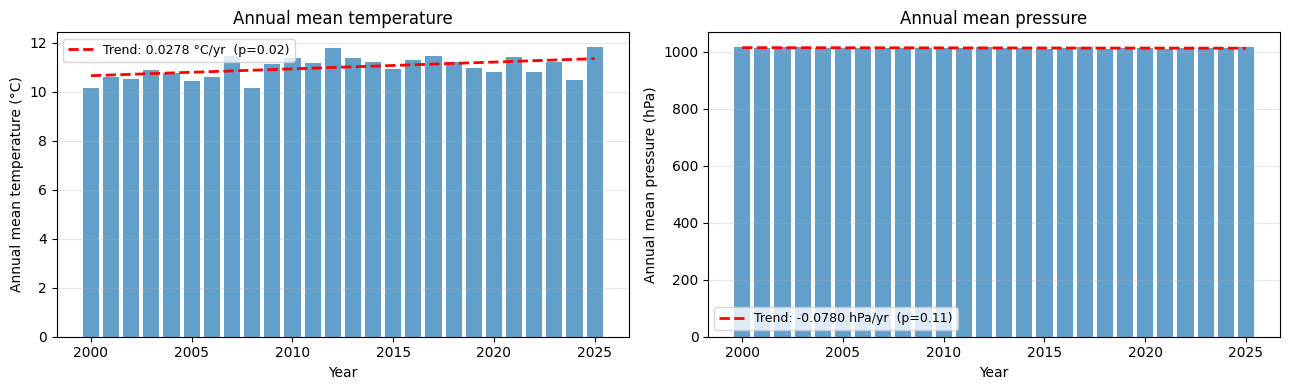

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, yr, vals, sl, ic, pv, label, units in [
    (axes[0], years, temperature_trend, slope,  intercept,  p,  'Annual mean temperature', '°C'),
    (axes[1], years, pressure_flat,     slope2, intercept2, p2, 'Annual mean pressure',    'hPa'),
]:
    ax.bar(yr, vals, alpha=0.7)
    x_line = np.array([yr[0], yr[-1]])
    ax.plot(x_line, sl * x_line + ic, 'r--', linewidth=2,
            label=f'Trend: {sl:.4f} {units}/yr  (p={pv:.2f})')
    ax.set_xlabel('Year')
    ax.set_ylabel(f'{label} ({units})')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

---
## Summary

| Method | When to use | Key function |
|---|---|---|
| Descriptive stats | Always — first thing to compute | `np.mean/std/percentile`, `.describe()` |
| Normalised histogram | Before fitting any distribution | `plt.hist(..., density=True)` |
| Normal fit | Pressure, temperature | `scipy.stats.norm.fit(data)` |
| Weibull fit | Wind speed | `scipy.stats.weibull_min.fit(data, floc=0)` |
| Exceedance curve | Identifying extreme events | Sort descending, plot on semilogy |
| Groupby | Monthly / seasonal climatology | `df.groupby(df['time'].dt.month).agg(...)` |
| Resampling | Changing temporal resolution | `df.set_index('time').resample('h').mean()` |
| Linear regression | Detecting long-term trends | `scipy.stats.linregress(x, y)` |

You are now ready to apply these methods to the real Chilbolton Observatory datasets.